<center><h1>Eigenvalue approximation</h1></center>
<center><h3>The general and symmetric power methods</h3></center>

- - - - - - - - - - - - - - -

In [1]:
import numpy as np
from IPython.display import Image

In statistics, the distribution of a set of points $p^{(s)} \in \mathbb{R}^{n}$ $(s = 1, \dots, m)$ can be described in terms of a mean vector $\mu \in \mathbb{R}^{n}$ and a symmetric, positive-definite covariance matrix $A \in \mathbb{R}^{n \times n}$ defined as
<center>$$\mu_{i} = \dfrac{1}{m} \sum_{s = 1}^{m} p_{i}^{(s)}$$</center>
<center>$$A_{ij} = \dfrac{1}{m} \sum_{s = 1}^{m} (p_{i}^{(s)} - \mu_{i})(p_{j}^{(s)} - \mu_{j})$$</center>

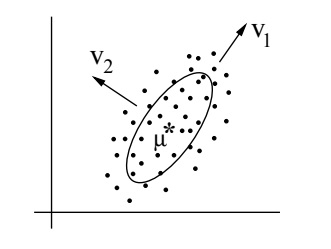

In [2]:
Image('vectors.jpg')

The vector $\mu$ and the eigenpairs ($\lambda, v$) of $A$ define the standard-deviation ellipsoid for the data: $\mu$ defines the center, and each $v$ defines an axis of ellipsoid with corresponding radius $\sqrt{\lambda}$. Here we find the center and maximum radius for a set of data $p^{(s)} \in \mathbb{R}^{4}$ $(s = 1, \dots, 100)$ using different power methods.

In [3]:
col1 = np.array([1.6757, 2.8330, 0.7356, 1.8980, 1.2357, 0.9174, 1.0523, 1.3439, 2.8451, 0.9997,
                3.9136, -1.6163, 2.0077, 4.0453, 1.3435, 0.6293, 0.2062, 1.2690, 4.1757, -1.6885,
                1.6745, 3.0160, -0.2223, 1.7365, 0.6248, 2.2605, 1.4369, 1.1167, 1.5001, -0.2435,
                4.4608, 3.2343, 2.6995, 3.2397, 4.8617, 4.4561, 3.4830, 1.4400, 0.3106, 2.0399,
                1.0800, 1.9716, 2.4303, 1.8899, 2.2631, 1.1528, 6.0911, -0.7565, 2.6915, 2.0320,
                2.4796, 2.2639, 1.6569, -1.2973, 3.1187, 1.5491, 1.9120, 1.1616, 1.0232, 3.6582,
                0.8471, 0.1211, 0.7893, 3.4122, 2.3950, 1.9631, 2.6933, 1.4611, 4.6016, 0.2056,
                3.3500, 2.0127, 1.1366, -0.5138, 3.2247, 1.5059, -0.3189, 0.1045, 3.3255, 2.8553,
                3.1130, 4.6411, 2.4679, 3.3101, 0.8400, 1.8864, 1.7965, 3.8046, 1.7432, 3.0711,
                1.2207, 5.0039, 3.2091, 2.7321, 1.0758, 2.0209, 2.7251, -2.3724, 0.5224, 0.3609])
col2 = np.array([-0.0530, 2.8357, 1.9748, 1.7982, 0.9826, 1.1790, 0.5897, 3.4589, 2.7171, 2.5520,
                2.2897, -1.2523, 1.3379, 1.6861, 3.0315, 1.4178, 0.2731, 1.0991, 2.7957, 1.7208,
                -0.1292, -0.4408, 2.6917, 1.5684, 3.5438, 1.4657, 0.0303, 1.0871, -0.0481, 1.9561,
                1.5954, 3.5727, 1.2671, -0.0016, 2.2830, 2.5859, 1.5327, 1.9292, 2.2299, 6.1578,
                1.8243, 3.4382, 1.0894, 4.0990, 5.3273, 4.8434, 2.9150, -0.5112, 3.0554, 2.5944,
                0.8536, 0.1786, 2.1555, 4.0840, 1.8542, 0.6953, 5.0975, 1.2969, 3.4949, 4.0547,
                -0.6337, 0.6827, 2.6089, 3.9676, 0.8989, 2.0090, 2.4667, 4.1140, 1.5851, 1.1218,
                4.1418, 3.0180, 2.8732, 0.6205, -0.9681, 2.3192, 3.2255, 0.4810, 0.7078, 4.9681,
                0.4361, 3.2952, 1.4548, 1.9978, 3.4955, 2.3347, 2.3538, 2.3627, -0.0647, 2.6772,
                1.3077, 1.9380, 0.9835, 1.9780, 4.1333, 1.5231, 1.8587, 0.3389, -0.5721, 0.5943])
col3 = np.array([0.3324, 1.1532, 0.3808, 0.6595, 0.9541, -0.5278, 0.5123, 1.9910, 1.3749, -1.7265,
                1.2038, 1.4749, -1.2706, -2.3876, 2.1693, -1.1859, -0.0923, 0.0907, -0.2022, 4.8503,
                0.1506, 0.4081, 2.1772, -0.8603, 1.9891, 2.1539, -0.1368, 2.3055, -2.2128, 2.9261,
                1.3383, 0.6167, -0.4785, -0.2422, 0.5434, 0.7876, -0.3004, 0.5462, 3.3960, 2.9081,
                1.3601, 2.2800, 1.0963, 2.1622, 4.9749, 1.1431, 0.6661, -0.4004, 4.3509, 1.3375,
                -0.0441, 0.2508, 0.8271, 4.0404, 1.4205, 0.4419, 2.7850, 3.7250, -0.0561, 6.0346,
                -0.1559, 2.9147, 3.3973, 1.6748, 0.5106, 2.1922, 1.3674, 2.1643, -0.0588, 2.7917,
                0.3848, 0.6982, 1.3444, 2.9124, -1.8201, 1.2573, 1.6822, -0.8746, -1.6695, 2.0069,
                1.8212, 1.0591, 1.9075, 2.4215, 2.9417, 1.0661, 2.7119, -1.7312, 0.0610, 0.7025,
                0.4932, 0.8518, 0.7053, 3.5032, 3.1050, 2.4737, 2.5584, 0.9127, -0.3948, -0.3035])
col4 = np.array([3.4410, 3.5933, 1.9283, 4.5336, 3.7002, 1.9360, 4.7297, 3.8246, 4.6047, 1.9553,
                3.5939, 3.6795, 3.1845, 1.5367, 4.1048, 2.9256, 2.9938, 3.4370, 2.3599, 5.0871,
                4.6123, 3.9058, 6.1379, 3.3014, 3.3363, 5.3374, 3.8101, 5.4160, 3.1341, 5.7031,
                4.9140, 2.3450, 3.2245, 4.2400, 2.9510, 2.9356, 4.0444, 3.7877, 5.9506, 4.1884,
                3.2234, 5.0026, 4.8904, 4.3217, 3.8743, 3.2756, 3.1303, 2.8226, 5.6889, 2.7182,
                3.2489, 4.6182, 4.3014, 5.1620, 4.2731, 3.8046, 2.5205, 5.5763, 4.2536, 7.0775,
                3.0518, 6.3553, 5.3560, 3.5732, 4.7097, 5.1043, 4.0573, 3.4029, 2.9965, 5.7855,
                1.2054, 2.5411, 4.6184, 5.3342, 2.3522, 2.3732, 3.1024, 4.0194, 3.3998, 3.9362,
                5.5793, 3.3447, 4.3151, 4.8868, 4.1257, 4.4954, 5.5231, 3.4977, 4.6899, 3.0267,
                4.3711, 2.8435, 3.3084, 7.2972, 2.7180, 4.3662, 5.6463, 3.2679, 3.5481, 2.9461])

Use the <b>general power method</b> to approximate the most dominant eigenvalue of matrix $A$ to within a tolerance of $||\lambda^{-1}Ax - x||_{\infty} < 10^{-4}$. Report the initial vector used, the number of iterations, approximate eigenvalues and the unit eigenvector. Are the results the same for different choices of the initial vector? What is the maximum radius of the ellipsoid?

In [4]:
def gen_power(datapt, n, m, maxIter, tol):
    mu = [0] * n
    A = [[0] * n] * n
    covar_A = []
    
    iter = 0
    pindex = 0
    error = 1
    
    for i in range(n):
        mu_sum = 0
        for s in range(m):
            mu_sum += (datapt[i][s])
        mu[i] = (1/m) * mu_sum
    
    for i in range(n):
        for j in range(n):
            a_sum = 0
            for s in range(m):
                a_sum += ((datapt[i][s] - mu[i]) * (datapt[j][s] - mu[j]))
            A[i][j] = (1/m) * a_sum
            covar_A.append(A[i][j])
    covar_A = np.asarray(covar_A).reshape(4, 4)

    init_x = [1] * n
    x = np.multiply(1/init_x[pindex], init_x)
    
    while(iter < maxIter and error >= tol):
        y = covar_A @ x
        lbda = y[pindex]
        
        for j in range(n):
            if abs(y[j]) > abs(y[pindex]):
                pindex = j
        r = np.multiply(1/lbda, y) - x
        error = np.linalg.norm(r, ord = np.inf)
        x = np.multiply(1/y[pindex], y)
        iter += 1
    
    print('Given A =')
    print(covar_A)
    print('Given x =')
    print(init_x)
    print(f'The solution converged with a |r|_(infinity) = {min(r)}')
    print(f'Iterations needed: {iter}')
    print(f'Approximate eigenvalue: lambda^(k) = {lbda}')
    print(f'Maximum radium: sqrt(lambda) = {np.sqrt(lbda)}')
    print('Approximate eigenvector: x^(k) =')
    print(x)

if __name__ == "__main__":
    datapt = [col1, col2, col3, col4]
    n = len(datapt)
    m = len(datapt[0])
    gen_power(datapt, n, m, 35, 1e-4)

Given A =
[[ 2.33291082  0.43608884 -0.47098964 -0.30787168]
 [ 0.43608884  2.19320709  1.12830288 -0.05564128]
 [-0.47098964  1.12830288  2.53626167  1.20446624]
 [-0.30787168 -0.05564128  1.20446624  1.38376036]]
Given x =
[1, 1, 1, 1]
The solution converged with a |r|_(infinity) = -7.540306935602259e-05
Iterations needed: 24
Approximate eigenvalue: lambda^(k) = 3.901518046516823
Maximum radium: sqrt(lambda) = 1.9752260747865857
Approximate eigenvector: x^(k) =
[-0.23458908  0.58459221  1.          0.49413307]


Repeat the above process using the <b>symmetric power method</b> with the same initial vectors, but with the tolerance condition $||\lambda^{-1}Ax - x||_{2} < 10^{-4}$. Notice that the <b>symmetric power method</b> is based on the 2-norm whereas the general power method is based on the $\infty$-norm. Are the eigenvalues and eigenvectors the same (up to scaling) as above?

In [5]:
def sym_power(datapt, n, m, maxIter, tol):
    mu = [0] * n
    A = [[0] * n] * n
    covar_A = []

    iter = 0
    error = 1
    
    for i in range(n):
        mu_sum = 0
        for s in range(m):
            mu_sum += (datapt[i][s])
        mu[i] = (1/m) * mu_sum
        
    for i in range(n):
        for j in range(n):
            a_sum = 0
            for s in range(m):
                a_sum += ((datapt[i][s] - mu[i]) * (datapt[j][s] - mu[j]))
            A[i][j] = (1/m) * a_sum
            covar_A.append(A[i][j])
    covar_A = np.asarray(covar_A).reshape(4, 4)

    init_x = [1] * n
    y = init_x
    
    while(iter < maxIter and error >= tol):
        ynorm = np.linalg.norm(y)
        x = np.multiply(1/ynorm, y)
        pindex = 0
        for j in range(n):
            if abs(x[j]) > abs(x[pindex]):
                pindex = j
        y = covar_A @ x
        lbda = np.dot(x, y)
        r = np.multiply(1/lbda, y) - x
        error = np.linalg.norm(r)
        iter += 1

    print('Given A =')
    print(covar_A)
    print('Given x =')
    print(init_x)
    print(f'The solution converged with a |r|_(infinity) = {min(r)}')
    print(f'Iterations needed: {iter}')
    print(f'Approximate eigenvalue: lambda^(k) = {lbda}')
    print(f'Maximum radium: sqrt(lambda) = {np.sqrt(lbda)}')
    print('Approximate eigenvector: x^(k) =')
    print(x)

if __name__ == "__main__":
    datapt = [col1, col2, col3, col4]
    n = len(datapt)
    m = len(datapt[0])
    sym_power(datapt, n, m, 35, 1e-4)

Given A =
[[ 2.33291082  0.43608884 -0.47098964 -0.30787168]
 [ 0.43608884  2.19320709  1.12830288 -0.05564128]
 [-0.47098964  1.12830288  2.53626167  1.20446624]
 [-0.30787168 -0.05564128  1.20446624  1.38376036]]
Given x =
[1, 1, 1, 1]
The solution converged with a |r|_(infinity) = -5.94533372039463e-05
Iterations needed: 24
Approximate eigenvalue: lambda^(k) = 3.901505463498869
Maximum radium: sqrt(lambda) = 1.9752228895744572
Approximate eigenvector: x^(k) =
[-0.18307095  0.45640076  0.7806408   0.3857244 ]


## Further readings:
Reading material:<br>
https://www.amazon.com/Numerical-Analysis-Richard-L-Burden/dp/1305253663/

The @ symbol: <br>
https://stackoverflow.com/questions/6392739/what-does-the-at-symbol-do-in-python

## Useful links:
Quick definition:<br>
https://faculty.washington.edu/trogdon/105A/html/Lecture22.html